# ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

EXPLICAÇÃO DO QUE FOI ANÁLISADO...

In [3]:
# Bibliotecas utilizadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carregamento da base de dados
df = pd.read_csv('vendas_aguas_LGPD_tratada.csv', delimiter=';')

df.head()

,id_cliente,dt_entrega,dt_semana,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_frequencia_pedidos,cli_media_aguas_por_pedido,cli_total_pedidos,target_dt_proxima_compra,target_dias_ate_recompra,target_vai_comprar_15d
0,89,2023-01-02,Segunda,1,03/03,NaN,Verão,2023.0,1.0,0,5.91,1,1.01,1,2023-01-11,9,1
1,102,2023-01-02,Segunda,1,0,NaN,Verão,2023.0,1.0,0,NaN,1,1.00,1,NaN,0,0
2,120,2023-01-02,Segunda,2,0,NaN,Verão,2023.0,1.0,0,14.07,1,1.93,1,2023-01-18,16,0
3,50,2023-01-02,Segunda,2,0,NaN,Verão,2023.0,1.0,0,7.80,1,2.03,1,2023-01-09,7,1
4,8,2023-01-02,Segunda,1,07/10,NaN,Verão,2023.0,1.0,0,6.15,1,1.00,1,2023-01-06,4,1


**Atribuições das variáveis:** \
id_cliente = Identificador anonimizado do cliente; \
dt_entrega = Data de entrega da água; \
dt_semana = Dia da semana da entrega da água; \
qtd_aguas_entregues = Quantidade de vasilhames entregues no dia; \
qtd_aguas_ticket = Quantidade de tickets sendo utilizados; \
obs_pedido = Observações sobre a entrega; \
dt_estacao = Estação do ano da entrega; \
dt_ano = Apenas o ano da entrega; \
dt_mes = Apenas o mês da entrega; \
cli_dias_desde_ultimo_pedido = Quantidade de dias desde a última compra realizada pelo cliente; \
cli_intervalo_medio = Média de dias que o cliente leva entre um pedido e outro; \
cli_frequencia_pedidos = Quantidade total de pedidos acumulados do cliente até o momento; \
cli_media_aguas_por_pedido = Média de vasilhames comprados por pedido pelo cliente; \
cli_total_pedidos = Histórico total de pedidos feitos pelo cliente na base de dados; \
target_dt_proxima_compra = Data em que o cliente realizou o pedido seguinte (usada para calcular o alvo); \
target_dias_ate_recompra = Quantidade exata de dias entre o pedido atual e o próximo; \
target_vai_comprar_15d = Variável alvo binária (1 = comprou em até 15 dias, 0 = demorou mais de 15 dias ou não comprou).

In [7]:
# Paleta de cores padrão do projeto
PALETA = {
    "azul": "#4477AA",
    "vermelho": "#EE6677",
    "verde": "#228833",
    "roxo": "#AA3377",
    "amarelo": "#C8A600",
    "cinza": "#BEBEBE",
    "preto": "#000000"
}

## 1º - Perfil geral dos pedidos
Objetivo: compreender como os pedidos estão distribuídos ao longo do período analisado, identificando padrões de consumo, sazonalidade e comportamento da operação antes de analisar o perfil dos clientes.

### A) Distribuição da quantidade de águas entregues:

C:\Users\nneto\AppData\Local\Temp\ipykernel_17028\4013904047.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


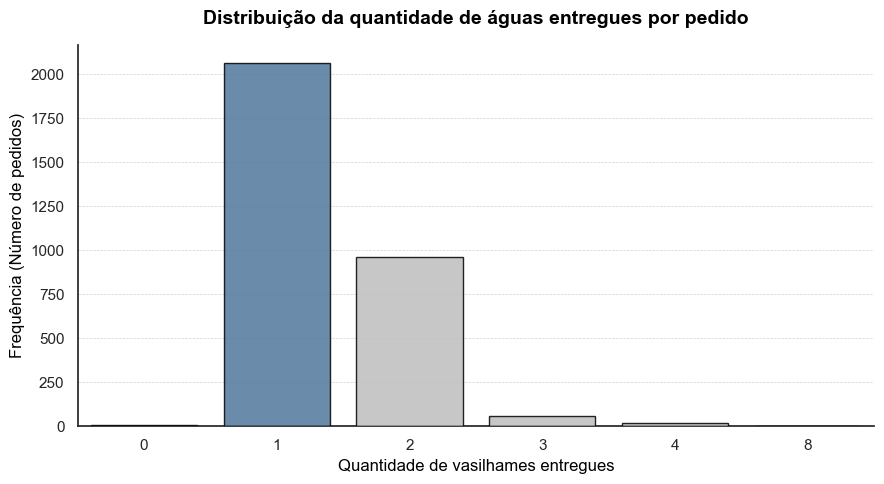

In [18]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(9, 5))

# Lógica para identificar qual quantidade tem o maior número de vendas (frequência)
frequencias = df['qtd_aguas_entregues'].value_counts()
maior_venda_qtd = frequencias.idxmax()

# Criação do mapeamento de cores dinâmico para cada barra
# O valor com maior frequência ganha "azul", se não, ganha "cinza"
cores_mapeadas = [
    PALETA["azul"] if valor == maior_venda_qtd else PALETA["cinza"] 
    for valor in sorted(df['qtd_aguas_entregues'].unique())
]

# Grades ao fundo
plt.grid(True, which='both', axis='both', color=PALETA["cinza"], linestyle='--', linewidth=0.5, alpha=0.7)

# Plotagem do gráfico usando countplot
sns.countplot(
    data=df, 
    x='qtd_aguas_entregues', 
    palette=cores_mapeadas,
    edgecolor=PALETA["preto"],
    alpha=0.85,
    zorder=3
)

# Remoção das bordas superior e direita
sns.despine(top=True, right=True)

# Títulos e rótulos
plt.title('Distribuição da quantidade de águas entregues por pedido', fontsize=14, pad=15, fontweight='bold', color=PALETA["preto"])
plt.xlabel('Quantidade de vasilhames entregues', fontsize=12, color=PALETA["preto"])
plt.ylabel('Frequência (Número de pedidos)', fontsize=12, color=PALETA["preto"])

# Ajuste do layout
plt.tight_layout()
plt.show()

**Insights:** \
O gráfico mostra que a venda de vasilhames se concentra em entregas de baixo volume. Os pedidos de 1 vasilhame lideram com mais de 2.000 registros, seguidos por cerca de 1.000 pedidos de 2 unidades. Juntas, essas duas faixas representam a esmagadora maioria do histórico. Em contraste, os pedidos de 3 e 4 vasilhames têm presença residual (abaixo de 250 registros cada), enquanto as faixas de 0 e 8 unidades não possuem dados expressivos na escala.

### B) Evolução da demanda ao longo do tempo:

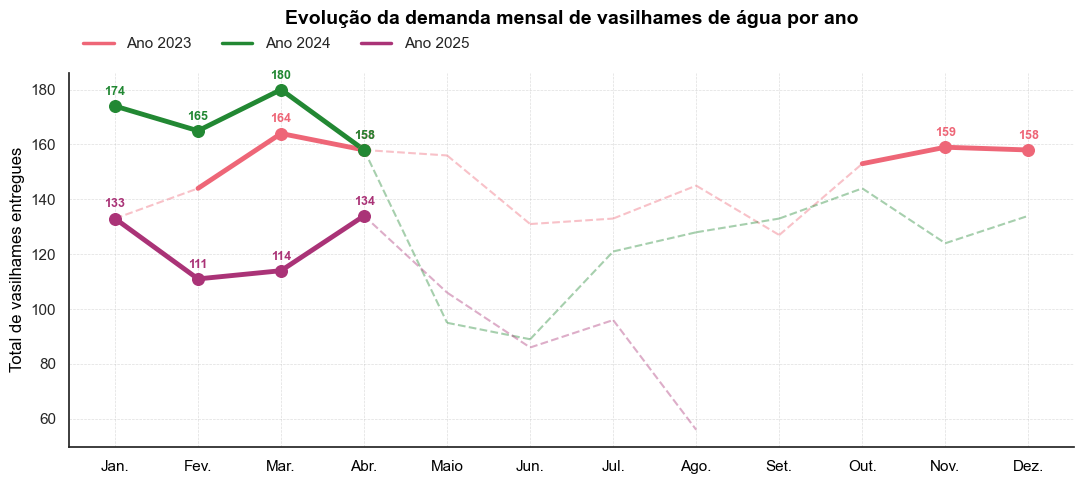

In [34]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(11, 5))

# Agrupamento dos dados por Ano e Mês, ordenando cronologicamente
demanda_temporal = df.groupby(['dt_ano', 'dt_mes'])['qtd_aguas_entregues'].sum().reset_index()
demanda_temporal = demanda_temporal.sort_values(['dt_ano', 'dt_mes']).reset_index(drop=True)

# Definição das cores vibrantes exclusivas para a identidade de cada ano
anos = sorted(demanda_temporal['dt_ano'].unique())
cores_vibrantes = [PALETA["vermelho"], PALETA["verde"], PALETA["roxo"], PALETA["amarelo"]]
cores_ano = {ano: cores_vibrantes[i % len(cores_vibrantes)] for i, ano in enumerate(anos)}

# Grades ao fundo
plt.grid(True, which='both', axis='both', color=PALETA["cinza"], linestyle='--', linewidth=0.5, alpha=0.5)

# Plotagem baseada no comportamento individual de cada ano
for ano in anos:
    dados_ano = demanda_temporal[demanda_temporal['dt_ano'] == ano].sort_values('dt_mes').reset_index(drop=True)
    
    # TRATAMENTO DO BUG DE 2025: Se o ano for 2025 e houver meses zerados/incompletos no fim, remove
    if ano == 2025:
        dados_ano = dados_ano[dados_ano['qtd_aguas_entregues'] > 10].reset_index(drop=True)
        
    # Identifica os 4 maiores picos específicos DESTE ano
    top_4_do_ano = dados_ano.nlargest(4, 'qtd_aguas_entregues')['dt_mes'].tolist()
    cor_base = cores_ano[ano]
    
    # Desenha as linhas ligando os meses para este ano específico
    for i in range(len(dados_ano) - 1):
        mes_prox = dados_ano.loc[i+1, 'dt_mes']
        
        if mes_prox in top_4_do_ano:
            linewidth = 3.5          
            linestyle = '-'          
            alpha = 1.0              
        else:
            linewidth = 1.5          
            linestyle = '--'         
            alpha = 0.4              
            
        plt.plot(
            dados_ano.loc[i:i+1, 'dt_mes'], 
            dados_ano.loc[i:i+1, 'qtd_aguas_entregues'], 
            color=cor_base, 
            linewidth=linewidth, 
            linestyle=linestyle,
            alpha=alpha,
            zorder=3 if mes_prox in top_4_do_ano else 2
        )
        
    # Linha invisível para gerar a legenda com a cor contínua do ano
    plt.plot([], [], color=cor_base, linewidth=2.5, label=f'Ano {int(ano)}')

    # Adiciona pontos e numeração apenas nos 4 maiores picos deste ano específico
    for idx, row in dados_ano.iterrows():
        mes = row['dt_mes']
        valor = row['qtd_aguas_entregues']
        
        if mes in top_4_do_ano:
            plt.scatter(mes, valor, color=cor_base, s=70, zorder=4)
            
            plt.annotate(
                f'{int(valor)}', 
                (mes, valor), 
                textcoords="offset points", 
                xytext=(0, 8), 
                ha='center', 
                fontsize=9, 
                fontweight='bold', 
                color=cor_base,
                zorder=5
            )

# Remoção das bordas superior e direita
sns.despine(top=True, right=True)

# Títulos e rótulos personalizados
plt.title('Evolução da demanda mensal de vasilhames de água por ano', fontsize=14, pad=35, fontweight='bold', color=PALETA["preto"])
plt.ylabel('Total de vasilhames entregues', fontsize=12, color=PALETA["preto"])

# Lista com os nomes dos meses abreviados para o eixo X
meses_abreviados = ['Jan.', 'Fev.', 'Mar.', 'Abr.', 'Maio', 'Jun.', 'Jul.', 'Ago.', 'Set.', 'Out.', 'Nov.', 'Dez.']
plt.xticks(range(1, 13), meses_abreviados, color=PALETA["preto"])

plt.legend(frameon=False, loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=len(anos))

plt.tight_layout()
plt.show()

**Insights:** \
O gráfico revela padrões consistentes e a evolução real do negócio:

- **Sazonalidade no 1º quadrimestre:** O pico de vendas no início dos anos se confirma como um padrão de mercado. Os maiores volumes ocorrem entre janeiro e abril, atingindo o topo em março, com 164 vasilhames em 2023 e 180 em 2024.
- **Crescimento ano a ano:** No primeiro quadrimestre, o ano de 2024 (linha verde) operou consistentemente acima de 2023 (linha vermelha), indicando expansão da carteira de clientes ou aumento no consumo.
- **Dados incompletos em 2025 (Linha roxa):** O ano iniciou em um patamar inferior aos anteriores. A queda a partir de maio e o encerramento em agosto não refletem uma crise, mas sim a ausência de registros.
- **Recuperação no final do ano:** O histórico de 2023 mostra que, após a retração do inverno (maio a setembro), ocorre uma reação forte na demanda a partir de outubro, mantendo patamares elevados de quase 160 vasilhames mensais até dezembro.

### C) Distribuição dos pedidos por dia da semana (dt_semana):

Ideias de gráfico:

Gráfico de barras

## 2º - Perfil dos clientes
Objetivo: compreender o histórico de consumo dos clientes e identificar padrões comportamentais que possam explicar a frequência de compras e a recompra.

### A) Histórico de compras dos clientes (cli_total_pedidos):

Ideias de gráficos:

Histograma \
Boxplot

### B) Intervalo médio entre compras (cli_intervalo_medio):

Ideias de gráficos:

Histograma \
Boxplot

### C) Média de águas por pedido (cli_media_aguas_por_pedido):

Ideias de gráficos:

Histograma \
Boxplot

### D) Frequência histórica de compras (cli_frequencia_pedidos):

Ideias de gráficos:

Histograma \
Boxplot

## 3º - Fatores que influenciam a recompra
Objetivo: identificar quais características dos clientes e dos pedidos apresentam maior relação com o tempo até a próxima compra.

### A) Quantidade de águas entregues × Dias até a recompra:

Variáveis:

- qtd_aguas_entregues
- target_dias_ate_recompra

Ideias de gráficos:

Boxplot \
Scatter Plot

### B) Intervalo médio entre compras × Dias até a recompra:

Variáveis:

- cli_intervalo_medio
- target_dias_ate_recompra

MUITO IMPORTANTE PARA VALIDAR A HIPÓTESE DO PROJETO, CITAR ELA...

Ideias de gráficos:

Scatter Plot com linha de tendência \
Boxplot

### C) Frequência de pedidos × Dias até a recompra:

Variáveis:

- cli_frequencia_pedidos
- target_dias_ate_recompra

Ideias de gráficos:

Scatter Plot \
Boxplot

### D) Total de pedidos × Dias até a recompra:

Variáveis:

- cli_total_pedidos
- target_dias_ate_recompra

Ideias de gráficos:

Scatter Plot \
Boxplot

### E) Média de águas por pedido × Dias até a recompra:

Variáveis:

- cli_media_aguas_por_pedido
- target_dias_ate_recompra

Ideias de gráficos:

Scatter Plot \
Boxplot

### F) Estação do ano × Dias até a recompra:

Variáveis:

- dt_estacao
- target_dias_ate_recompra

Ideias de gráfico:

Boxplot

## 4º - Correlação entre variáveis
Objetivo: validar estatisticamente as relações observadas durante a análise exploratória e identificar quais variáveis possuem maior potencial preditivo.

### A) Correlação entre as variáveis numéricas:

Gráfico:

Heatmap de correlação

## Conclusão